# Profissionais de saúde cadastrados

**Pergunta que este notebook responde:** quantos profissionais de saúde estão
cadastrados no estado, de quais ocupações, e como se distribuem entre os
municípios?

**Fonte:** CNES, grupo `PF` (profissionais).
**Tempo estimado:** 4 a 6 minutos.

## Preparação

In [2]:
%pip install pysus nest_asyncio -q
import nest_asyncio
nest_asyncio.apply()
print("Ambiente pronto.")

Note: you may need to restart the kernel to use updated packages.
Ambiente pronto.


## Parâmetros

In [3]:
UF = "PR"
ANO = 2024
MES = 12

## Passo 1 — Conferir o período

In [4]:
from pysus import list_files

catalogo = list_files(dataset="cnes", state=UF, year=ANO, month=MES)
tem_pf = any(nome.split("\\")[-1].startswith("PF") for nome in catalogo["name"])

print(f"Arquivos em {MES:02d}/{ANO}: {len(catalogo)}")
print(f"Grupo PF (profissionais) disponível? {'sim' if tem_pf else 'NÃO'}")

Arquivos em 12/2024: 12
Grupo PF (profissionais) disponível? sim


## Passo 2 — Baixar o cadastro de profissionais

No CNES o `group` é essencial — aqui, `PF`.

In [5]:
from pysus import cnes

profissionais = cnes(state=UF, year=ANO, month=MES, group="PF", as_dataframe=True)

print(f"{len(profissionais):,} vínculos profissionais em {UF}, {MES:02d}/{ANO}")

356,758 vínculos profissionais em PR, 12/2024


> **Atenção à leitura:** cada linha é um **vínculo**, não uma pessoa. Um mesmo
> profissional pode atender em vários estabelecimentos e aparecer várias vezes.
> A coluna `CPF_PROF` permite contar pessoas distintas.

In [6]:
if "CPF_PROF" in profissionais.columns:
    pessoas = profissionais["CPF_PROF"].nunique()
    print(f"Vínculos:              {len(profissionais):>10,}")
    print(f"Profissionais únicos:  {pessoas:>10,}")
    print(f"Vínculos por pessoa:   {len(profissionais)/pessoas:>10.2f}")
else:
    print("Colunas disponíveis:", [c for c in profissionais.columns][:20])

Vínculos:                 356,758
Profissionais únicos:     230,947
Vínculos por pessoa:         1.54


## Passo 3 — Ocupações mais frequentes

A ocupação vem no código **CBO** (Classificação Brasileira de Ocupações), na
coluna `CBO`. Os códigos mais comuns na saúde começam com:

| Início do CBO | Ocupação |
|---|---|
| `2251` / `2252` / `2253` | Médicos |
| `2235` | Enfermeiros |
| `3222` | Técnicos e auxiliares de enfermagem |
| `2236` | Fisioterapeutas |
| `2237` | Nutricionistas |
| `2232` | Cirurgiões-dentistas |
| `2515` | Psicólogos |

In [7]:
import pandas as pd

GRUPOS_CBO = {
    "2251": "Médico clínico", "2252": "Médico em especialidade cirúrgica",
    "2253": "Médico em medicina diagnóstica", "2231": "Médico (geral)",
    "2235": "Enfermeiro", "3222": "Técnico/auxiliar de enfermagem",
    "2236": "Fisioterapeuta", "2237": "Nutricionista",
    "2232": "Cirurgião-dentista", "2515": "Psicólogo",
    "2234": "Farmacêutico", "2516": "Assistente social",
    "3242": "Técnico de laboratório", "5151": "Agente comunitário de saúde",
}

profissionais["ocupacao"] = (
    profissionais["CBO"].astype(str).str[:4].map(GRUPOS_CBO)
)

por_ocupacao = (
    profissionais["ocupacao"].dropna()
    .value_counts()
    .rename_axis("Ocupação")
    .reset_index(name="Vínculos")
)
por_ocupacao

,Ocupação,Vínculos
0,Médico clínico,79343
1,Técnico/auxiliar de enfermagem,62030
2,Médico em especialidade cirúrgica,33239
3,Enfermeiro,27013
4,Agente comunitário de saúde,18663
5,Cirurgião-dentista,14892
6,Farmacêutico,10515
7,Fisioterapeuta,10068
8,Psicólogo,9158
9,Médico em medicina diagnóstica,4816


## Passo 4 — Em gráfico

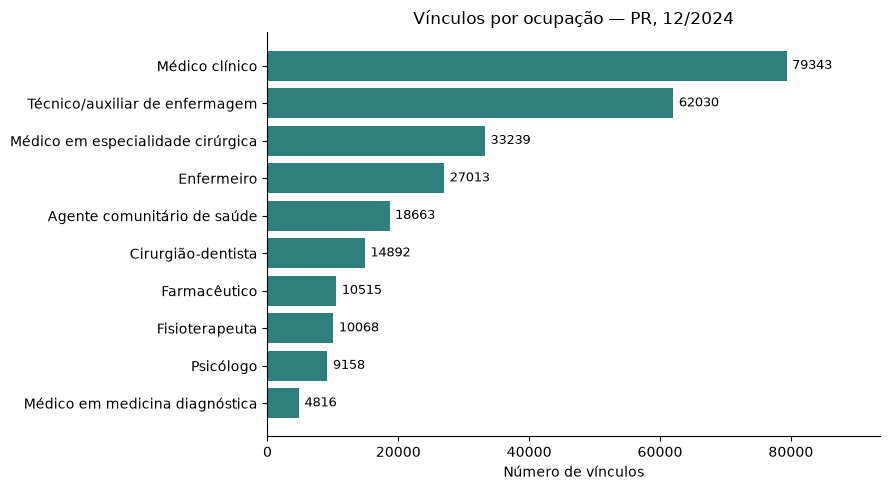

In [8]:
import matplotlib.pyplot as plt

grafico = por_ocupacao.head(10).sort_values("Vínculos")

fig, ax = plt.subplots(figsize=(9, 5))
barras = ax.barh(grafico["Ocupação"], grafico["Vínculos"], color="#2f7f7f")
ax.bar_label(barras, padding=4, fontsize=9)

ax.set_title(f"Vínculos por ocupação — {UF}, {MES:02d}/{ANO}", fontsize=12)
ax.set_xlabel("Número de vínculos")
ax.set_xlim(0, grafico["Vínculos"].max() * 1.18)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

## Passo 5 — Distribuição entre municípios

Onde estão os profissionais? Os dez municípios com mais vínculos:

In [9]:
por_municipio = (
    profissionais["CODUFMUN"]
    .value_counts()
    .head(10)
    .rename_axis("CODUFMUN")
    .reset_index(name="Vínculos")
)

try:
    municipios = pd.read_json("https://servicodados.ibge.gov.br/api/v1/localidades/municipios")
    nomes = {str(m["id"])[:6]: m["nome"] for _, m in municipios.iterrows()}
    por_municipio["Município"] = por_municipio["CODUFMUN"].map(nomes)
except Exception:
    por_municipio["Município"] = por_municipio["CODUFMUN"]

por_municipio[["Município", "Vínculos"]]

,Município,Vínculos
0,Curitiba,97916
1,Londrina,23655
2,Maringá,19054
3,Cascavel,16865
4,Ponta Grossa,10689
5,Foz do Iguaçu,8039
6,Campo Largo,7602
7,Guarapuava,6670
8,Umuarama,5621
9,Campo Mourão,5339


## Como adaptar

- **Outro estado, ano ou mês:** mude os parâmetros no início.
- **Uma ocupação específica:** filtre `CBO` pelo código de interesse — por
  exemplo, `profissionais[profissionais["CBO"].str.startswith("2235")]` para
  enfermeiros.
- **Profissionais por habitante:** combine com a população do IBGE para
  calcular a razão por mil habitantes, indicador usado em planejamento.
- **Vínculos SUS:** a coluna `VINCUL_C` indica o tipo de vínculo.

---
*Notebook do projeto [PySusNoCode](https://github.com/cartaproale/PySusNoCode) —
um produto [Kraemer Academy](https://kraemeracademy.net).
Validado com dados reais do DATASUS.*